# NextFlix — EDA & Modeling Notebook
**AI/ML Internship Task — Aakash Group**

This notebook covers the full exploratory analysis and modeling rationale.
For production training, use `python train.py`.

| Step | Description |
|------|-------------|
| 1 | Dataset exploration & EDA |
| 2 | Text preprocessing pipeline |
| 3 | TF-IDF vs BoW comparison |
| 4 | Recommendation demos |
| 5 | Evaluation metrics |

In [1]:
import re, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sns.set_style('darkgrid')
print('Imports Successful')

Imports Successful


## 1. Dataset Exploration

In [2]:
dataset  = load_dataset('jquigl/imdb-genres')
# train_df = pd.DataFrame(dataset['train'])
# val_df   = pd.DataFrame(dataset['validation'])

train_df = pd.read_csv('../dataset/train.csv')
val_df = pd.read_csv('../dataset/validation.csv')

print(f'Train : {train_df.shape}  |  Val : {val_df.shape}')
print(f'Columns: {list(train_df.columns)}')

Train : (238256, 5)  |  Val : (29809, 5)
Columns: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description']


In [3]:
train_df.rename(columns={'movie title - year': 'title'}, inplace=True)
train_df.head(3)

,title,genre,expanded-genres,rating,description
0,Flaming Ears - 1992,Fantasy,"Fantasy, Sci-Fi",6.0,Flaming Ears is a pop sci-fi lesbian fantasy f...
1,Jeg elsker dig - 1957,Romance,"Comedy, Drama, Romance",5.8,Six people - three couples - meet at random at...
2,Povjerenje - 2021,Thriller,Thriller,NaN,"In a small unnamed town, in year 2025, Krsto w..."


In [4]:
print('Missing values:\n', train_df.isnull().sum())
print(f'\nDuplicate titles: {train_df["title"].duplicated().sum()}')

Missing values:
 title                  0
genre                  0
expanded-genres        0
rating             69721
description            0
dtype: int64

Duplicate titles: 76475


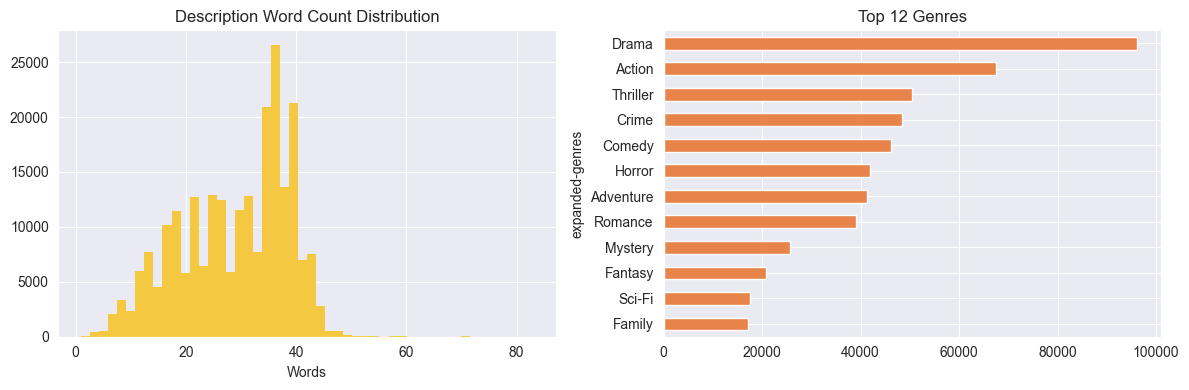

Avg description length: 29.0 words


In [5]:
import matplotlib.pyplot as plt

# ------------------ Description Length Analysis ------------------

# Compute word count for each movie description
train_df['desc_len'] = train_df['description'].str.split().str.len()

# Create subplot layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot histogram of description lengths
train_df['desc_len'].hist(
    bins=50,
    ax=axes[0],
    color='#f5c842',
    edgecolor='none'
)

# Customize plot
axes[0].set_title('Description Word Count Distribution')
axes[0].set_xlabel('Words')


# ------------------ Genre Distribution ------------------

# Dynamically find the genre column (handles different dataset schemas)
genre_col = next(
    (c for c in ['expanded-genres', 'genre', 'genres'] if c in train_df.columns),
    None
)

if genre_col:
    # Process genres:
    # - Remove missing values
    # - Split multiple genres (comma, pipe, slash)
    # - Flatten into individual rows
    # - Clean whitespace
    # - Count frequency
    genre_counts = (
        train_df[genre_col]
        .dropna()
        .str.split(r'[,|/]')   # split multiple genres
        .explode()             # flatten list into rows
        .str.strip()           # remove extra spaces
        .value_counts()
        .head(12)              # top 12 most frequent genres
    )
    
    # Plot genre distribution (horizontal bar chart)
    genre_counts.plot(
        kind='barh',
        ax=axes[1],
        color='#e8834a'
    )
    
    # Customize plot
    axes[1].set_title('Top 12 Genres')
    axes[1].invert_yaxis()  # highest count at top


# ------------------ Final Layout & Summary ------------------

# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Print average description length
print(f'Avg description length: {train_df["desc_len"].mean():.1f} words')

## 2. Text Preprocessing
Pipeline: **Lowercase → Remove punctuation → Remove stopwords → Lemmatise**

In [6]:
import re

def clean_text(text):
    # Handle non-string or empty values
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Replace multiple spaces with a single space and trim
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize, remove stopwords, filter short words, and lemmatize
    return ' '.join(
        lemmatizer.lemmatize(w)        # Convert word to its base form
        for w in text.split()          # Split text into words
        if w not in STOP_WORDS         # Remove common stopwords
        and len(w) > 2                 # Keep words longer than 2 characters
    )


# ---------------------- Demo ----------------------

# Get first movie description
sample = train_df['description'].iloc[0]

# Print original and cleaned text for comparison
print('ORIGINAL:\n', sample)
print('\nCLEANED:\n', clean_text(sample))


# ------------------ Apply to Dataset ------------------

# Create a new column with cleaned descriptions
train_df['clean_description'] = train_df['description'].apply(clean_text)

# Remove rows where cleaned text is empty after processing
train_df = train_df[train_df['clean_description'].str.strip() != ''].reset_index(drop=True)

# Print number of retained rows after cleaning
print(f'\nRetained: {len(train_df):,} movies')

ORIGINAL:
 Flaming Ears is a pop sci-fi lesbian fantasy feature set in the year 2700 in the fictive burned-out city of Asche. It follows the tangled lives of three women - Volley, Nun and Spy.

CLEANED:
 flaming ear pop sci lesbian fantasy feature set year fictive burned city asche follows tangled life three woman volley nun spy

Retained: 238,250 movies


## 3. TF-IDF vs BoW Comparison

| Method | Weights | Behaviour |
|--------|---------|----------|
| **BoW** | Raw count | 'film' and 'story' get high weight everywhere |
| **TF-IDF** | count × log(N/df) | Down-weights common words, up-weights rare discriminating terms |

BoW   matrix : (238250, 20000)
TF-IDF matrix: (238250, 20000)


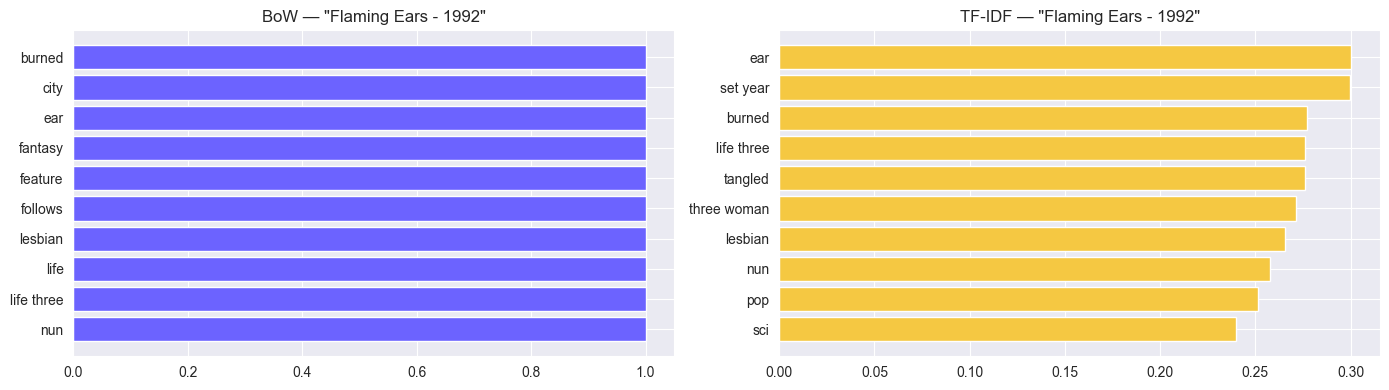

→ TF-IDF surfaces more specific, meaningful terms


In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt

# ------------------ Vectorizer Initialization ------------------

# Bag of Words (BoW) Vectorizer
# - max_features: limit vocabulary size
# - ngram_range: include unigrams and bigrams
# - min_df: ignore rare words (appear in < 2 documents)
bow_vec = CountVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2
)

# TF-IDF Vectorizer
# - sublinear_tf: apply log scaling to term frequency
tfidf_vec = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)


# ------------------ Fit & Transform ------------------

# Convert cleaned text into numerical feature matrices
bow_mat   = bow_vec.fit_transform(train_df['clean_description'])
tfidf_mat = tfidf_vec.fit_transform(train_df['clean_description'])

# Print matrix shapes (rows = documents, columns = features)
print(f'BoW   matrix : {bow_mat.shape}')
print(f'TF-IDF matrix: {tfidf_mat.shape}')


# ------------------ Term Importance Comparison ------------------

# Select a sample movie (index 0)
idx = 0
movie_title = train_df['title'].iloc[idx]

# Convert sparse row to dense array and map terms to scores
bow_scores = dict(zip(
    bow_vec.get_feature_names_out(),      # vocabulary terms
    bow_mat[idx].toarray()[0]             # corresponding counts
))

tfidf_scores = dict(zip(
    tfidf_vec.get_feature_names_out(),    # vocabulary terms
    tfidf_mat[idx].toarray()[0]           # TF-IDF scores
))

# Get top 10 terms based on score (descending order)
top_bow = sorted(
    bow_scores.items(),
    key=lambda x: -x[1]
)[:10]

top_tfidf = sorted(
    tfidf_scores.items(),
    key=lambda x: -x[1]
)[:10]


# ------------------ Visualization ------------------

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Unpack terms and scores for plotting
terms_b, scores_b = zip(*top_bow)
terms_t, scores_t = zip(*top_tfidf)

# Plot BoW top terms
axes[0].barh(terms_b, scores_b, color='#6c63ff')
axes[0].set_title(f'BoW — "{movie_title}"')
axes[0].invert_yaxis()  # Highest score at top

# Plot TF-IDF top terms
axes[1].barh(terms_t, scores_t, color='#f5c842')
axes[1].set_title(f'TF-IDF — "{movie_title}"')
axes[1].invert_yaxis()

# Adjust layout and display
plt.tight_layout()
plt.show()


# ------------------ Insight ------------------

# Observation: TF-IDF highlights more meaningful and specific terms
print('→ TF-IDF surfaces more specific, meaningful terms')

## 4. Recommendation Demos

In [8]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ------------------ Title Index Mapping ------------------

# Map movie titles (lowercased) to their DataFrame indices
# This allows fast lookup for title-based recommendations
title_index = pd.Series(
    train_df.index,
    index=train_df['title'].str.lower()
)


# ------------------ Recommendation by Title ------------------

def recommend_by_title(title, n=5):
    """
    Recommend top-N similar movies based on a given movie title.
    
    Args:
        title (str): Movie title to base recommendations on.
        n (int): Number of recommendations to return.
    
    Returns:
        pd.DataFrame: Top-N recommended movies with their description and similarity score.
    """
    
    # Normalize title to lowercase
    key = title.lower()
    
    # Return empty DataFrame if title not found
    if key not in title_index:
        return pd.DataFrame()
    
    # Get index of the movie
    idx = title_index[key]
    
    # Handle case where multiple movies have same title (take the first one)
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    
    # Compute cosine similarity between this movie and all others
    scores = cosine_similarity(tfidf_mat[idx], tfidf_mat).flatten()
    
    # Exclude the movie itself from recommendations
    scores[idx] = -1
    
    # Sort indices by similarity (descending)
    top = scores.argsort()[::-1]
    
    # Filter indices to valid range and select top-N
    top = [i for i in top if i < len(train_df)][:n]
    
    # Create result DataFrame with title, description, and score
    res = train_df.iloc[top][['title', 'description']].copy()
    res['score'] = scores[top].round(4)
    
    return res.reset_index(drop=True)


# ------------------ Recommendation by Query ------------------

def recommend_by_query(query, n=5):
    """
    Recommend top-N movies based on a free-text query.
    
    Args:
        query (str): User query string.
        n (int): Number of recommendations to return.
    
    Returns:
        pd.DataFrame: Top-N recommended movies with description and similarity score.
    """
    
    # Clean and vectorize the input query
    vec = tfidf_vec.transform([clean_text(query)])
    
    # Compute similarity between query vector and all movie vectors
    scores = cosine_similarity(vec, tfidf_mat).flatten()
    
    # Sort indices by similarity (descending) and select top-N safely
    top = scores.argsort()[::-1]
    top = [i for i in top if i < len(train_df)][:n]
    
    # Create result DataFrame
    res = train_df.iloc[top][['title', 'description']].copy()
    res['score'] = scores[top].round(4)
    
    return res.reset_index(drop=True)


# ------------------ Demo ------------------

# Select a sample movie from dataset
demo = train_df['title'].iloc[0]

# Display recommendations based on movie title
print(f'Similar to "{demo}":')
display(recommend_by_title(demo)[['title', 'score']])

print()

# Display recommendations based on a free-text query
print('Space adventure query:')
display(
    recommend_by_query('space adventure unlikely hero saving galaxy')[['title', 'score']]
)

Similar to "Flaming Ears - 1992":


,title,score
0,Flaming Ears - 1992,1.0000
1,Teen Kanya - 2012,0.2506
2,Tribhanga - 2021,0.2442
3,Porcelain Presence - nan,0.2360
4,The Husband's Secret - nan,0.2223



Space adventure query:


,title,score
0,Tekiya no Ishimatsu - 1976,0.4666
1,Tekiya no Ishimatsu - 1976,0.4666
2,The Reptilian Man - nan,0.4248
3,Leap - V,0.4115
4,The Baron Of Valley Forge - nan,0.4009


## 5. Evaluation

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **ILS** | avg pairwise cosine sim in top-N list | Lower = more diverse |
| **Avg score** | mean cosine sim to query | Higher = more relevant |
| **Coverage** | % of catalogue ever recommended | Higher = less popularity bias |

Mean ILS (diversity, lower=better) : 0.3412
Mean similarity score              : 0.4143
Catalogue coverage                 : 0.1%


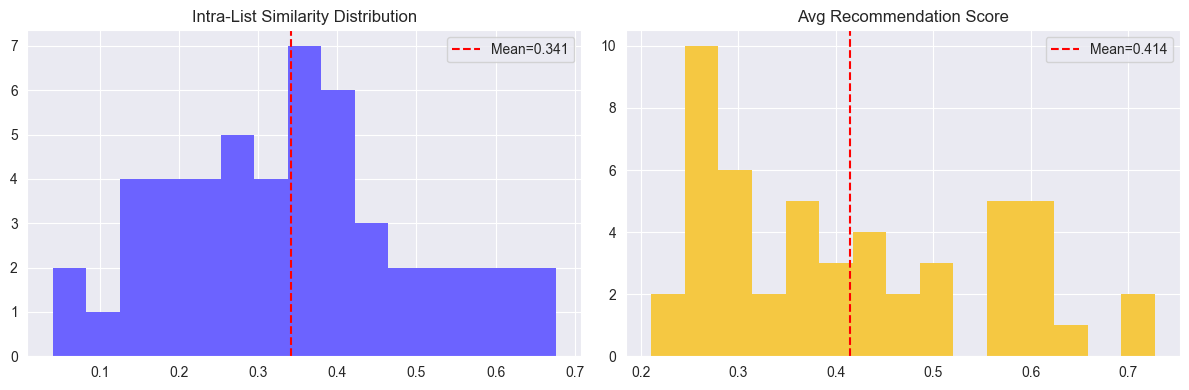

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# ------------------ Sample Movies for Evaluation ------------------

# Randomly sample 50 movie titles to evaluate recommendations
sample_titles = train_df['title'].sample(
    50,
    random_state=42  # ensures reproducibility
).tolist()

# Initialize tracking variables
ils_scores = []   # Intra-List Similarity (ILS) for diversity
avg_scores = []   # Average similarity score of recommendations
seen = set()      # Unique recommended titles (for catalog coverage)


# ------------------ Evaluation Loop ------------------

for title in sample_titles:
    
    # Get recommendations for the current movie
    recs = recommend_by_title(title)
    
    # Skip if no recommendations found
    if recs.empty:
        continue
    
    # Track all recommended titles for coverage calculation
    seen.update(recs['title'].tolist())
    
    # Compute average similarity score for this recommendation list
    avg_scores.append(recs['score'].mean())
    
    # ------------------ Build Safe List of Indices ------------------
    
    indices = []
    for t in recs['title']:
        idx = title_index.get(t.lower())
        if idx is None:
            continue
        
        # Handle duplicate titles by taking the first occurrence
        if isinstance(idx, pd.Series):
            idx = idx.iloc[0]
        
        indices.append(idx)
    
    # Compute Intra-List Similarity (ILS) if enough items exist
    if len(indices) >= 2:
        sub = tfidf_mat[indices]             # subset of TF-IDF vectors
        sim = cosine_similarity(sub)         # pairwise similarity within recommendation list
        np.fill_diagonal(sim, 0)             # ignore self-similarity
        ils_scores.append(sim.sum() / (len(indices)*(len(indices)-1)))  # average pairwise similarity


# ------------------ Summary Metrics ------------------

# Mean ILS (lower = more diverse recommendations)
print(f'Mean ILS (diversity, lower=better) : {np.mean(ils_scores):.4f}')

# Mean similarity score of recommendations
print(f'Mean similarity score              : {np.mean(avg_scores):.4f}')

# Catalogue coverage (% of unique recommended items)
print(f'Catalogue coverage                 : {len(seen)/len(train_df)*100:.1f}%')


# ------------------ Visualization ------------------

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot ILS distribution
axes[0].hist(
    ils_scores,
    bins=15,
    color='#6c63ff',
    edgecolor='none'
)
axes[0].axvline(
    np.mean(ils_scores),
    color='red',
    linestyle='--',
    label=f'Mean={np.mean(ils_scores):.3f}'
)
axes[0].set_title('Intra-List Similarity Distribution')
axes[0].legend()

# Plot average recommendation score distribution
axes[1].hist(
    avg_scores,
    bins=15,
    color='#f5c842',
    edgecolor='none'
)
axes[1].axvline(
    np.mean(avg_scores),
    color='red',
    linestyle='--',
    label=f'Mean={np.mean(avg_scores):.3f}'
)
axes[1].set_title('Avg Recommendation Score')
axes[1].legend()

# Adjust layout and display plots
plt.tight_layout()
plt.show()

## 6. Limitations & Improvements

### Limitations
1. **No semantic understanding** — 'car chase' ≠ 'automobile pursuit' in TF-IDF space
2. **Cold-start** — very short descriptions produce sparse, poor-quality vectors
3. **No personalisation** — purely content-based; ignores user history
4. **Scalability** — full cosine similarity is O(n²); impractical at > 100k movies
5. **Description quality bias** — verbose summaries dominate recommendations

### Improvements
| Approach | Benefit |
|----------|---------|
| Sentence Transformers (SBERT) | Semantic similarity, handles paraphrases |
| BM25 instead of TF-IDF | Better short-query ranking |
| FAISS / Annoy ANN search | O(log n) retrieval at scale |
| Collaborative filtering (ALS) | Adds user-preference signal |
| Hybrid model (content + CF) | Best-of-both accuracy |